Completed 180 validation-only configurations.
Best configuration: {"feature_set": "genres+tags+decade", "popularity_weight": 1.0, "profile_mode": "centered", "use_decade": true, "use_genre": true, "use_tag": true, "w_decade": 0.3, "w_genre": 1.0, "w_tag": 0.0}
Best content metrics: {'precision@10': 0.0315884476534296, 'recall@10': 0.07652197890439012, 'ndcg@10': 0.06533435950103633, 'map@10': 0.038257263194086295, 'coverage': 0.0487579552453295, 'novelty': 9.083247217054266, 'users_evaluated': 554}


,feature_set,w_tag,profile_mode,popularity_weight,precision@10,recall@10,ndcg@10,coverage,novelty
124,genres+tags+decade,0.00,centered,1.0,0.0316,0.0765,0.0653,0.0488,9.0832
139,genres+tags+decade,0.25,centered,1.0,0.0312,0.0764,0.0649,0.0497,9.1045
19,genres,0.25,centered,1.0,0.0303,0.0757,0.0642,0.0438,8.9996
4,genres,0.00,centered,1.0,0.0303,0.0757,0.0642,0.0438,8.9996
49,genres,1.00,centered,1.0,0.0303,0.0757,0.0642,0.0438,8.9996
64,genres+tags,0.00,centered,1.0,0.0303,0.0757,0.0642,0.0438,8.9996
34,genres,0.50,centered,1.0,0.0303,0.0757,0.0642,0.0438,8.9996
79,genres+tags,0.25,centered,1.0,0.0300,0.0752,0.0642,0.0449,9.0078
154,genres+tags+decade,0.50,centered,1.0,0.0300,0.0730,0.0632,0.0506,9.1700
169,genres+tags+decade,1.00,centered,1.0,0.0301,0.0750,0.0630,0.0472,9.1613


,feature_set,w_tag,profile_mode,popularity_weight,ndcg@10,coverage,novelty
0,genres+tags+decade,0.0,centered,1.0,0.0653,0.0488,9.0832
1,genres,0.0,centered,1.0,0.0642,0.0438,8.9996
2,genres+tags,0.0,centered,1.0,0.0642,0.0438,8.9996


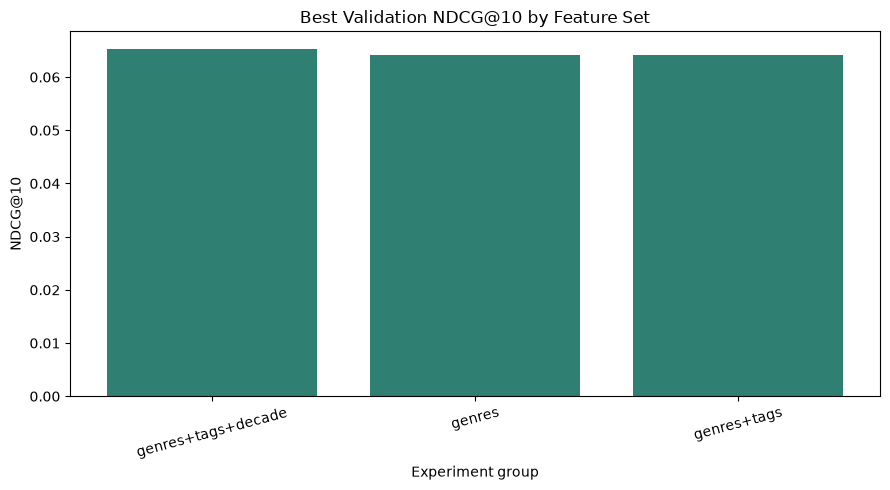

Nearest neighbors for Toy Story (1995):


,title,cosine_score
0,Antz (1998),1.000000
1,Toy Story 2 (1999),1.000000
2,We're Back! A Dinosaur's Story (1993),0.966545
3,Kirikou and the Sorceress (Kirikou et la sorci...,0.966545
4,Little Nemo: Adventures in Slumberland (1992),0.938830
5,Space Jam (1996),0.918701
6,"Adventures of Rocky and Bullwinkle, The (2000)",0.917431
7,"Monsters, Inc. (2001)",0.917431
8,"Wild, The (2006)",0.917431
9,"Tale of Despereaux, The (2008)",0.917431


Nearest neighbors for Dark Knight, The (2008):


,title,cosine_score
0,Batman Begins (2005),0.967067
1,Need for Speed (2014),0.917431
2,Eagle Eye (2008),0.903031
3,"Fast Five (Fast and the Furious 5, The) (2011)",0.855229
4,Night at the Museum: Battle of the Smithsonian...,0.820979
5,"Good Day to Die Hard, A (2013)",0.820462
6,"Fast & Furious 6 (Fast and the Furious 6, The)...",0.820462
7,"Grandmaster, The (Yi dai zong shi) (2013)",0.816714
8,"Dark Knight Rises, The (2012)",0.802163
9,RoboCop (2014),0.790084


Nearest neighbors for Casablanca (1942):


,title,cosine_score
0,Penny Serenade (1941),1.0
1,Brief Encounter (1946),1.0
2,"Now, Voyager (1942)",1.0
3,"Magnificent Ambersons, The (1942)",1.0
4,Jane Eyre (1944),1.0
5,"Heiress, The (1949)",1.0
6,Random Harvest (1942),1.0
7,Mr. Skeffington (1944),1.0
8,"All This, and Heaven Too (1940)",1.0
9,The Blue Lagoon (1949),1.0


In [3]:
import sys; sys.path.append("..")

import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import ARTIFACTS, DATA_PROC, REPORTS, REL_THRESHOLD, TOP_K
from src.evaluate import evaluate_ranking
from src.models.content import ContentBased, build_item_features

train = pd.read_parquet(DATA_PROC / "train.parquet")
val = pd.read_parquet(DATA_PROC / "val.parquet")
movies = pd.read_parquet(DATA_PROC / "movies.parquet")
n_users = 610
n_items = len(movies)
assert np.array_equal(movies["i"].to_numpy(), np.arange(n_items))

feature_specs = [
    {"feature_set": "genres", "use_tag": False, "use_decade": False, "tag_weights": [0.0, 0.25, 0.5, 1.0]},
    {"feature_set": "genres+tags", "use_tag": True, "use_decade": False, "tag_weights": [0.0, 0.25, 0.5, 1.0]},
    {"feature_set": "genres+tags+decade", "use_tag": True, "use_decade": True, "tag_weights": [0.0, 0.25, 0.5, 1.0]},
]
profile_modes = ["centered", "ones", "liked"]
popularity_weights = [0.0, 0.1, 0.25, 0.5, 1.0]

class CachedScores:
    def __init__(self, score_matrix):
        self.score_matrix = score_matrix

    def score_user(self, user):
        return self.score_matrix[int(user)]


search_records = []
for spec in feature_specs:
    for w_tag in spec["tag_weights"]:
        features, _ = build_item_features(
            movies,
            w_genre=1.0,
            w_tag=w_tag,
            w_decade=0.3,
            use_genre=True,
            use_tag=spec["use_tag"],
            use_decade=spec["use_decade"],
        )
        for profile_mode in profile_modes:
            profile_model = ContentBased(
                features, profile_mode=profile_mode, popularity_weight=0.0
            ).fit(train, n_users, n_items)
            content_scores = np.vstack(
                [profile_model.score_user(user) for user in range(n_users)]
            )
            for popularity_weight in popularity_weights:
                trial_scores = (
                    content_scores
                    + popularity_weight * profile_model.item_popularity_z
                )
                ranking = evaluate_ranking(
                    CachedScores(trial_scores),
                    train,
                    val,
                    n_items=n_items,
                    k=TOP_K,
                    thr=REL_THRESHOLD,
                )
                params = {
                    "feature_set": spec["feature_set"],
                    "w_genre": 1.0,
                    "w_tag": w_tag,
                    "w_decade": 0.3,
                    "profile_mode": profile_mode,
                    "popularity_weight": popularity_weight,
                }
                search_records.append(
                    {
                        **params,
                        "precision@10": ranking["precision@10"],
                        "recall@10": ranking["recall@10"],
                        "ndcg@10": ranking["ndcg@10"],
                        "coverage": ranking["coverage"],
                        "novelty": ranking["novelty"],
                        "users_evaluated": ranking["users_evaluated"],
                        "params": json.dumps(params, sort_keys=True),
                    }
                )

search_results = pd.DataFrame(search_records)
REPORTS.mkdir(parents=True, exist_ok=True)
search_results.to_csv(REPORTS / "content_search.csv", index=False)

best_index = search_results["ndcg@10"].idxmax()
best_row = search_results.loc[best_index]
best_config = {
    "feature_set": best_row["feature_set"],
    "w_genre": float(best_row["w_genre"]),
    "w_tag": float(best_row["w_tag"]),
    "w_decade": float(best_row["w_decade"]),
    "use_genre": True,
    "use_tag": best_row["feature_set"] != "genres",
    "use_decade": best_row["feature_set"] == "genres+tags+decade",
    "profile_mode": best_row["profile_mode"],
    "popularity_weight": float(best_row["popularity_weight"]),
}
ARTIFACTS.mkdir(parents=True, exist_ok=True)
with (ARTIFACTS / "content_config.json").open("w", encoding="utf-8") as config_file:
    json.dump(best_config, config_file, indent=2, sort_keys=True)

best_features, _ = build_item_features(movies, **{
    key: best_config[key]
    for key in (
        "w_genre", "w_tag", "w_decade", "use_genre", "use_tag", "use_decade"
    )
})
content_model = ContentBased(
    best_features,
    profile_mode=best_config["profile_mode"],
    popularity_weight=best_config["popularity_weight"],
).fit(train, n_users, n_items)
content_metrics = evaluate_ranking(
    content_model, train, val, n_items=n_items, k=TOP_K, thr=REL_THRESHOLD
)

baseline_results_path = REPORTS / "results_val.csv"
results_val = pd.read_csv(baseline_results_path)
random_ndcg = results_val.loc[
    (results_val["model"] == "random") & (results_val["metric"] == "ndcg@10"),
    "value",
].iloc[-1]
popularity_count_coverage = results_val.loc[
    (results_val["model"] == "popularity_count")
    & (results_val["metric"] == "coverage"),
    "value",
].iloc[-1]
assert content_metrics["ndcg@10"] > random_ndcg
assert content_metrics["coverage"] > popularity_count_coverage

content_params = json.dumps(best_config, sort_keys=True)
content_rows = [
    {
        "model": "content",
        "split": "val",
        "metric": metric,
        "value": value,
        "params": content_params,
    }
    for metric, value in content_metrics.items()
]
results_val = results_val.loc[results_val["model"] != "content"]
results_val = pd.concat([results_val, pd.DataFrame(content_rows)], ignore_index=True)
results_val = results_val[["model", "split", "metric", "value", "params"]]
results_val.to_csv(baseline_results_path, index=False)

feature_summary = (
    search_results.loc[search_results.groupby("feature_set")["ndcg@10"].idxmax()]
    .sort_values("ndcg@10", ascending=False)
    [["feature_set", "w_tag", "profile_mode", "popularity_weight", "ndcg@10", "coverage", "novelty"]]
    .reset_index(drop=True)
)
top_trials = search_results.sort_values("ndcg@10", ascending=False).head(10)
print(f"Completed {len(search_results)} validation-only configurations.")
print("Best configuration:", json.dumps(best_config, sort_keys=True))
print("Best content metrics:", content_metrics)
display(top_trials[["feature_set", "w_tag", "profile_mode", "popularity_weight", "precision@10", "recall@10", "ndcg@10", "coverage", "novelty"]].round(4))
display(feature_summary.round(4))

plot_dir = REPORTS / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(feature_summary["feature_set"], feature_summary["ndcg@10"], color="#2f7f72")
ax.set(title="Best Validation NDCG@10 by Feature Set", xlabel="Experiment group", ylabel="NDCG@10")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(plot_dir / "content_experiments.png", dpi=160)
plt.show()

queries = ["Toy Story (1995)", "The Dark Knight (2008)", "Casablanca (1942)"]
for query in queries:
    matched = movies.loc[movies["title"] == query]
    if matched.empty:
        title_core, year_text = query.rsplit(" (", 1)
        title_core = title_core.removeprefix("The ")
        year_text = year_text.rstrip(")")
        title_mask = movies["title"].str.contains(
            re.escape(title_core), case=False, regex=True
        ) & movies["title"].str.endswith(f"({year_text})")
        matched = movies.loc[title_mask]
    assert not matched.empty, f"Could not find movie title for {query}"
    query_movie = matched.iloc[0]
    neighbor_indices, neighbor_scores = content_model.similar_items(
        int(query_movie["i"]), n=10
    )
    neighbors = pd.DataFrame(
        {
            "title": movies.iloc[neighbor_indices]["title"].to_numpy(),
            "cosine_score": neighbor_scores,
        }
    )
    print(f"Nearest neighbors for {query_movie['title']}:")
    display(neighbors)

### Validation finding
The best content configuration (centered profile, genres + tags + decade, tag weight 0.0, popularity weight 1.0) reaches NDCG@10 = 0.0653 versus 0.0638 for count popularity. Content also improves coverage (0.0488 vs. 0.0089) and novelty (9.0832 vs. 8.4866), trading a modest ranking gain for broader, less-popular recommendations.